# Fase 4 — Análisis multivariado, contraste de hipótesis y baseline P6

| Campo | Valor |
|---|---|
| **Entrada** | `compounds_all.csv` (~147, análisis estructural) + `compounds_features.csv` (potencia, ~89) + `activities_clean.csv` |
| **Salidas** | `stats_tests.csv`, `clustering_summary.json`, `baseline_honest_metrics.csv`, figuras PCA/clustering/baseline |
| **Doc** | [`docs/fases/fase4_modelado.md`](../docs/fases/fase4_modelado.md) (§12 = baseline) |

## Por qué no hay modelado supervisado como producto principal

- `activity_class` es binarización de `pchembl_value >= 6` → **circular**.
- `pchembl_median_binding` (solo BINDING_TYPES) es el target de potencia; el embudo 147→89 excluye compuestos solo-censurados → **sesgo al alza**.
- `pct_active` es derivado de `pchembl ≥ 6` — **no independiente**.
- Split por filas = **fuga** (métricas infladas). Split por compuesto → **no generaliza**.

El **baseline predictivo honesto (P6)** se ejecuta en la **§4** de este mismo notebook.


## 0. Configuración

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

import _bootstrap
from src.paths import PROJECT_ROOT as ROOT, setup_path
setup_path()

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

FIG_DIR = ROOT / "outputs" / "chembl" / "figures"
RESULTS_DIR = ROOT / "outputs" / "chembl" / "results"
for d in (FIG_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

import json
import sys
from scipy.cluster import hierarchy

# Descartar módulos cacheados del kernel (evita ImportError tras cambios en src/)
for _mod in [k for k in list(sys.modules) if k.startswith("src.analisis_proyecto")]:
    del sys.modules[_mod]

from src.analisis_proyecto.modeling.baseline import (
    CompoundLevelBaseline,
    RowLevelSplitContrast,
)
from src.analisis_proyecto.modeling.multivariate import (
    MULTIVARIATE_FEATURE_COLS,
    apply_multiple_testing_correction,
    cluster_vs_family_ari,
    kruskal_by_family,
    posthoc_dunn,
    run_kmeans_silhouette,
    run_pca,
    scale_features,
)
from src.analisis_proyecto.preprocessing.pipeline import FEATURE_COLS, load_bioactivity

COMPOUNDS_ALL_CSV = ROOT / "data" / "processed" / "compounds_all.csv"
COMPOUNDS_POTENCY_CSV = ROOT / "data" / "processed" / "compounds_features.csv"
COMPOUNDS_CSV = COMPOUNDS_ALL_CSV  # alias retrocompatible
ACTIVITIES_CSV = ROOT / "data" / "processed" / "activities_clean.csv"
FUNNEL_JSON = RESULTS_DIR / "corpus_funnel.json"
assert COMPOUNDS_ALL_CSV.exists(), "Ejecuta fase2_limpieza.ipynb primero"
assert ACTIVITIES_CSV.exists(), "Ejecuta fase2_limpieza.ipynb primero"

compounds = pd.read_csv(COMPOUNDS_ALL_CSV)
compounds_potency = pd.read_csv(COMPOUNDS_POTENCY_CSV) if COMPOUNDS_POTENCY_CSV.exists() else compounds
activities = load_bioactivity(ACTIVITIES_CSV)
if FUNNEL_JSON.is_file():
    funnel = json.loads(FUNNEL_JSON.read_text(encoding="utf-8"))
    print(
        f"Embudo: {funnel['raw_compounds']} compuestos crudo -> "
        f"{funnel['with_potency_binding_min_support']} con potencia (sesgo documentado)"
    )
print(f"Estructural: {len(compounds)} | potencia: {len(compounds_potency)} | familias: {compounds['family'].nunique()}")


Embudo: 147 compuestos crudo -> 89 con potencia (sesgo documentado)
Estructural: 147 | potencia: 89 | familias: 7


## 1. PCA (descriptores escalados)

Varianza explicada PC1+PC2: 78.2%


,componente,varianza,loadings
0,PC1,0.465348,"[0.4109975571438931, -0.07802451062191629, 0.5..."
1,PC2,0.316663,"[0.3989629210914586, 0.625080288613032, -0.222..."


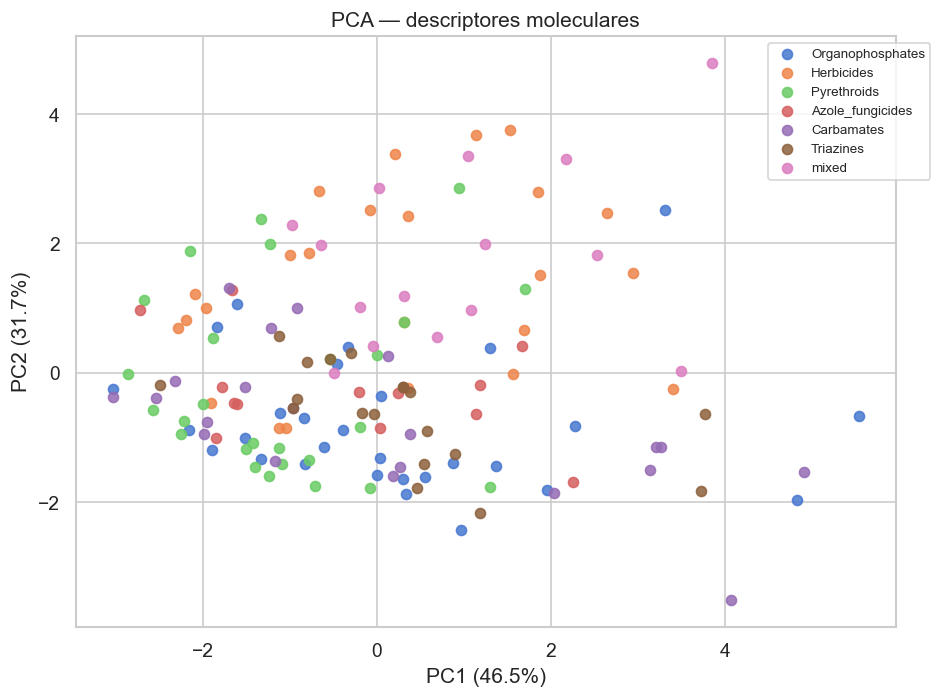

In [2]:
X = scale_features(compounds)
pca = run_pca(X, 2)
ev = pca["explained_variance_ratio"]
print(f"Varianza explicada PC1+PC2: {sum(ev)*100:.1f}%")
display(pd.DataFrame({
    "componente": ["PC1", "PC2"],
    "varianza": ev,
    "loadings": pca["loadings"],
}))

fig, ax = plt.subplots(figsize=(8, 6))
for fam in compounds["family"].unique():
    m = compounds["family"] == fam
    ax.scatter(pca["coords"][m, 0], pca["coords"][m, 1], label=fam, alpha=0.85)
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.set_title("PCA — descriptores moleculares")
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_scatter.png", bbox_inches="tight")
plt.show()


## 2. Clustering

Silhouette por k: {2: 0.3632759428412794, 3: 0.34298680799747033, 4: 0.2773740244406572, 5: 0.27958725107673005, 6: 0.2934569746884627, 7: 0.29516600568744594, 8: 0.28091407676913777}
best_k: 2


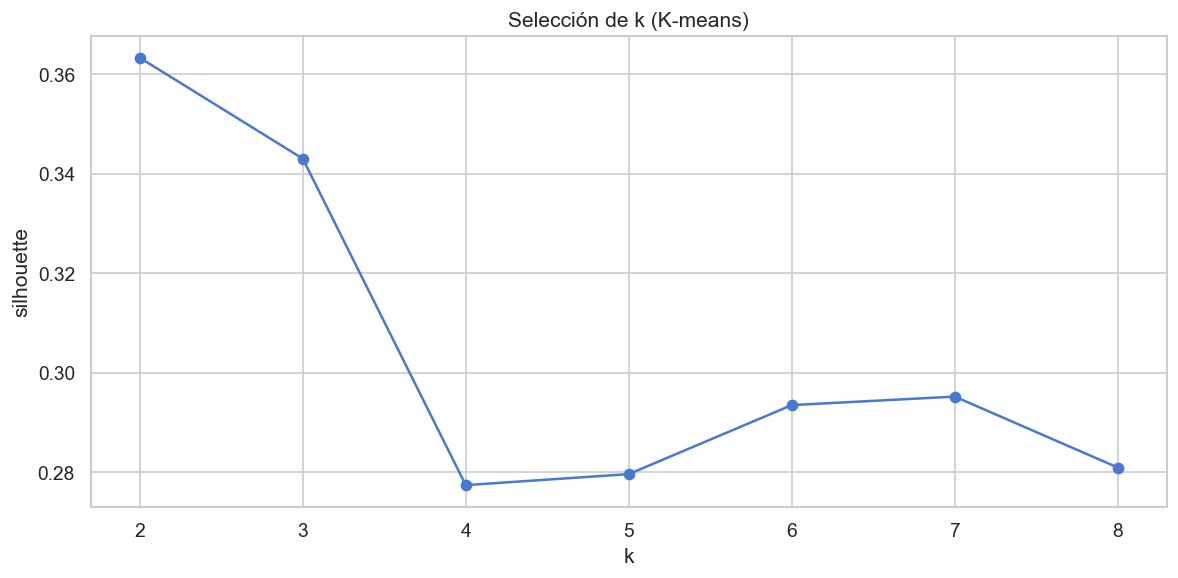

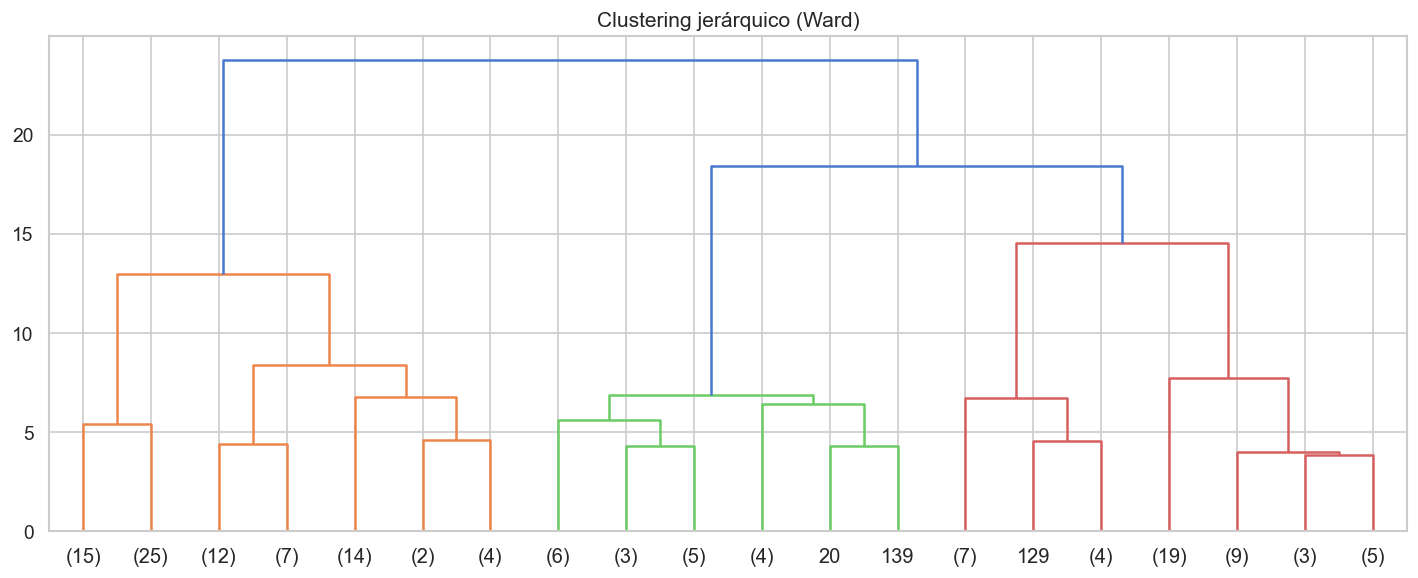

ARI clusters vs family: 0.018


In [3]:
km = run_kmeans_silhouette(X)
print("Silhouette por k:", km["silhouette_by_k"])
print("best_k:", km["best_k"])

fig, ax = plt.subplots()
ax.plot(list(km["silhouette_by_k"].keys()), list(km["silhouette_by_k"].values()), "o-")
ax.set_xlabel("k")
ax.set_ylabel("silhouette")
ax.set_title("Selección de k (K-means)")
plt.tight_layout()
plt.savefig(FIG_DIR / "cluster_silhouette.png", bbox_inches="tight")
plt.show()

Z = hierarchy.linkage(X, method="ward")
fig, ax = plt.subplots(figsize=(12, 5))
hierarchy.dendrogram(Z, ax=ax, truncate_mode="lastp", p=20)
ax.set_title("Clustering jerárquico (Ward)")
plt.tight_layout()
plt.savefig(FIG_DIR / "dendrogram.png", bbox_inches="tight")
plt.show()

labels = km["labels"]
ari = cluster_vs_family_ari(labels, compounds["family"])
print(f"ARI clusters vs family: {ari:.3f}")
compounds["cluster"] = labels
compounds.to_csv(COMPOUNDS_ALL_CSV, index=False)
compounds_potency = compounds_potency.drop(columns=["cluster"], errors="ignore").merge(
    compounds[["chembl_id", "cluster"]], on="chembl_id", how="left"
)
compounds_potency.to_csv(COMPOUNDS_POTENCY_CSV, index=False)


## 3. Tests Kruskal-Wallis + post-hoc Dunn

**Interpretación (importante):**
- Los descriptores fisicoquímicos que difieren entre familias son **caracterización descriptiva esperada por definición de familia** (circular), no un hallazgo de descubrimiento.
- La batería **confirmatoria** usa 7 descriptores (`MULTIVARIATE_FEATURE_COLS`), excluye `mixed`, y aplica corrección Benjamini-Hochberg (`p_adjusted`).
- `pchembl_median` va en tabla **exploratoria aparte** (mezcla endpoints heterogéneos).

Descriptores multivariado: ['mw_freebase', 'alogp', 'psa', 'hba', 'hbd', 'aromatic_rings', 'rtb']
Descartados: ['num_ro5_violations']

Post-hoc Dunn — mw_freebase (p_adj=0.0074):


,Azole_fungicides,Carbamates,Herbicides,Organophosphates,Pyrethroids,Triazines
Azole_fungicides,1.0000,1.0000,0.3477,1.0000,1.0000,1.0000
Carbamates,1.0000,1.0000,0.0657,1.0000,1.0000,1.0000
Herbicides,0.3477,0.0657,1.0000,0.0359,0.0007,0.3955
Organophosphates,1.0000,1.0000,0.0359,1.0000,1.0000,1.0000
Pyrethroids,1.0000,1.0000,0.0007,1.0000,1.0000,0.8906
Triazines,1.0000,1.0000,0.3955,1.0000,0.8906,1.0000



Post-hoc Dunn — alogp (p_adj=0.0001):


,Azole_fungicides,Carbamates,Herbicides,Organophosphates,Pyrethroids,Triazines
Azole_fungicides,1.0000,1.0000,0.2676,0.6377,1.0000,1.0000
Carbamates,1.0000,1.0000,0.0002,1.0000,1.0000,1.0000
Herbicides,0.2676,0.0002,1.0000,0.0000,0.0258,0.0042
Organophosphates,0.6377,1.0000,0.0000,1.0000,0.5902,1.0000
Pyrethroids,1.0000,1.0000,0.0258,0.5902,1.0000,1.0000
Triazines,1.0000,1.0000,0.0042,1.0000,1.0000,1.0000



Post-hoc Dunn — psa (p_adj=0.0337):


...


Post-hoc Dunn — rtb (p_adj=0.0074):


,Azole_fungicides,Carbamates,Herbicides,Organophosphates,Pyrethroids,Triazines
Azole_fungicides,1.0000,1.0000,1.0000,1.0000,0.4495,1.0000
Carbamates,1.0000,1.0000,1.0000,1.0000,0.1173,1.0000
Herbicides,1.0000,1.0000,1.0000,1.0000,0.0011,1.0000
Organophosphates,1.0000,1.0000,1.0000,1.0000,0.1173,1.0000
Pyrethroids,0.4495,0.1173,0.0011,0.1173,1.0000,0.0634
Triazines,1.0000,1.0000,1.0000,1.0000,0.0634,1.0000


,value_col,H,p,p_adjusted,epsilon2,k_groups,n,n_excluded_groups
0,mw_freebase,18.1805,0.0027,0.0074,0.1046,6,132,15
1,alogp,30.5534,0.0000,0.0001,0.2028,6,132,15
2,psa,12.4700,0.0289,0.0337,0.0593,6,132,15
3,hba,9.4311,0.0931,0.0931,0.0352,6,132,15
4,hbd,17.1462,0.0042,0.0074,0.0964,6,132,15
5,aromatic_rings,13.2725,0.0210,0.0293,0.0657,6,132,15
6,rtb,17.5460,0.0036,0.0074,0.0996,6,132,15


,value_col,H,p,p_adjusted,epsilon2,k_groups,n,n_excluded_groups,note
0,pchembl_median_binding,33.1941,0.0,None,0.3862,6,79,10,EXPLORATORIO — pchembl_median_binding solo BIN...


Partición exploratoria — no corresponde a familias (ARI=0.018, silhouette=0.36)

Hallazgo informativo: pchembl_median_binding NO separa familias (p=0.00) — los descriptores separan por estructura, no por actividad.


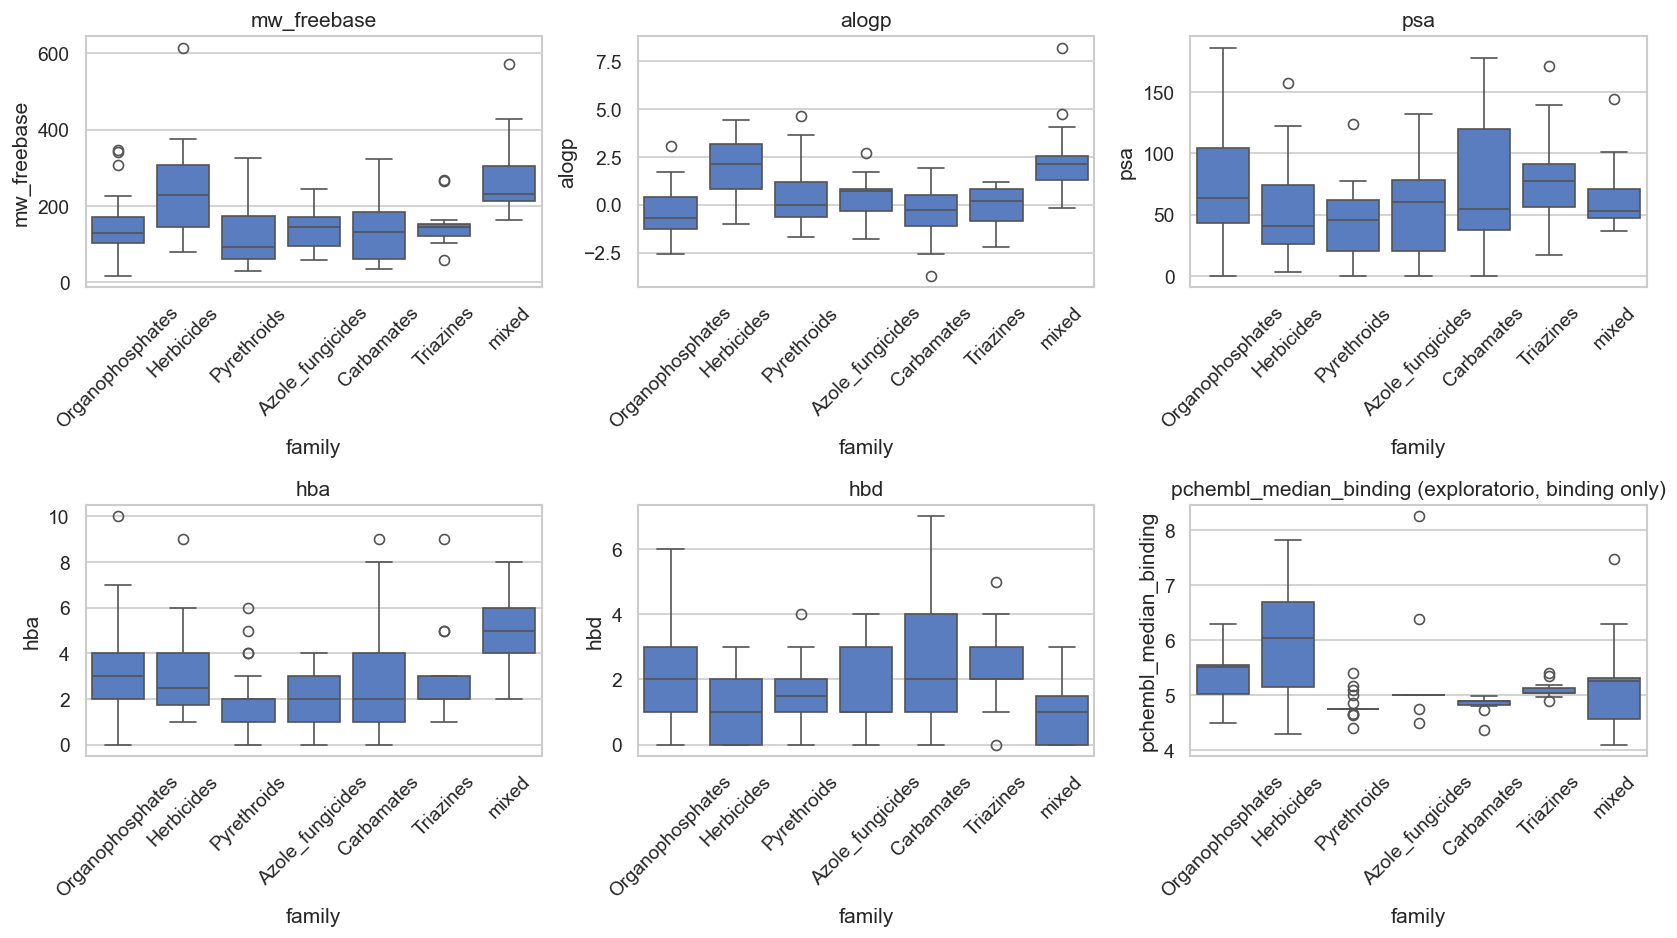

In [4]:
from src.analisis_proyecto.modeling.multivariate import (
    MULTIVARIATE_FEATURE_COLS,
    MultivariateAnalyzer,
    drop_degenerate,
)

feat_cols = [c for c in MULTIVARIATE_FEATURE_COLS if c in compounds.columns]
dropped = sorted(set(FEATURE_COLS) - set(MULTIVARIATE_FEATURE_COLS))
feat_cols, dropped_degen = drop_degenerate(compounds, feat_cols)
dropped = sorted(set(dropped) | set(dropped_degen))
print(f"Descriptores multivariado: {feat_cols}")
print(f"Descartados: {dropped}")

stats_rows = [
    kruskal_by_family(compounds, v, exclude_groups=("mixed",))
    for v in feat_cols
]
stats_rows = apply_multiple_testing_correction(stats_rows)
for res in stats_rows:
    if res.get("p_adjusted") is not None and res["p_adjusted"] < 0.05:
        col = res["value_col"]
        print(f"\nPost-hoc Dunn — {col} (p_adj={res['p_adjusted']:.4f}):")
        display(posthoc_dunn(compounds, col, exclude_groups=("mixed",)).round(4))

stats_df = pd.DataFrame(stats_rows)
display(stats_df.round(4))
stats_df.to_csv(RESULTS_DIR / "stats_tests.csv", index=False)

mv = MultivariateAnalyzer().analyze(compounds, potency_compounds=compounds_potency)
exploratory_df = pd.DataFrame(mv.exploratory_stats_rows)
display(exploratory_df.round(4))
exploratory_df.to_csv(RESULTS_DIR / "stats_tests_exploratory.csv", index=False)

(RESULTS_DIR / "clustering_summary.json").write_text(
    json.dumps(mv.summary, indent=2), encoding="utf-8"
)
print(mv.summary["cluster_validity_note"])

exploratory = mv.exploratory_stats_rows[0]
potency_p = exploratory.get("p")
if potency_p is not None:
    print(
        f"\nHallazgo informativo: pchembl_median_binding NO separa familias "
        f"(p={potency_p:.2f}) — los descriptores separan por estructura, no por actividad."
    )

boxplot_df = compounds.merge(
    compounds_potency[["chembl_id", "pchembl_median_binding"]],
    on="chembl_id",
    how="left",
)
boxplot_vars = feat_cols[:5] + ["pchembl_median_binding"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(boxplot_vars):
    sns.boxplot(data=boxplot_df, x="family", y=col, ax=axes.flatten()[i])
    axes.flatten()[i].tick_params(axis="x", rotation=45)
    title = col if col != "pchembl_median_binding" else f"{col} (exploratorio, binding only)"
    axes.flatten()[i].set_title(title)
plt.tight_layout()
plt.savefig(FIG_DIR / "family_boxplots_annotated.png", bbox_inches="tight")
plt.show()


## 4. Baseline predictivo honesto (P6)

Contraste que **aísla la fuga**: mismo target (`pchembl_value`), mismas filas (n=2807), solo cambia el split:
- `filas_KFold_CON_FUGA` — KFold aleatorio (fuga: mismo compuesto en train y test)
- `filas_GroupKFold_HONESTO` — GroupKFold por `chembl_id` (honesto)
- `compuesto` — vista complementaria a nivel agregado (`pchembl_median`, n=107)

Métrica primaria: **R² = media ± σ entre folds** (+ IC bootstrap 95%), nunca un punto de un split único.


,split,n,r2_cv_mean,r2_cv_std,r2_folds,r2_ci95_low,r2_ci95_high
0,filas_KFold_CON_FUGA,3509,0.4402,0.0158,0.451555|0.429871|0.414266|0.456223|0.449154,0.4248,0.4529
1,filas_GroupKFold_HONESTO,3509,-0.2293,0.1947,-0.544165|-0.025190|-0.323062|-0.224306|-0.029638,-0.3970,-0.0668
2,compuesto,89,-0.5157,0.4074,-1.022749|-0.253099|-1.002150|-0.143377|-0.157052,-0.8606,-0.1708


Diferencia entre filas-KFold y filas-GroupKFold es ÚNICAMENTE el split (mismo target, n=3509).


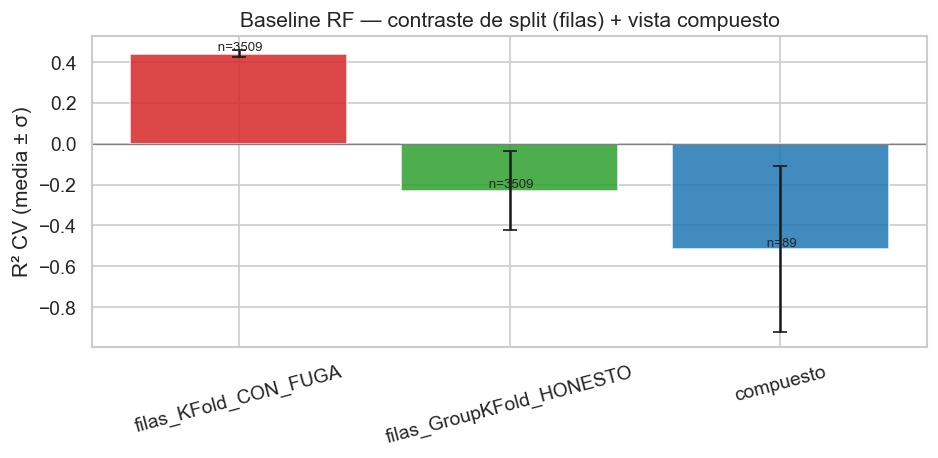

In [5]:
row_metrics = RowLevelSplitContrast().evaluate(activities)
compound_metric = CompoundLevelBaseline().evaluate(compounds_potency)
metrics = pd.DataFrame([m.to_dict() for m in row_metrics + [compound_metric]])
display(metrics.round(4))
metrics.to_csv(RESULTS_DIR / "baseline_honest_metrics.csv", index=False)

leak = metrics[metrics["split"] == "filas_KFold_CON_FUGA"].iloc[0]
honest = metrics[metrics["split"] == "filas_GroupKFold_HONESTO"].iloc[0]
assert leak["n"] == honest["n"], "Contraste filas: n debe ser idéntico"
print(
    f"Diferencia entre filas-KFold y filas-GroupKFold es ÚNICAMENTE el split "
    f"(mismo target, n={leak['n']})."
)

fig, ax = plt.subplots(figsize=(8, 4))
labels = metrics["split"]
means = metrics["r2_cv_mean"]
stds = metrics["r2_cv_std"]
colors = ["#d62728", "#2ca02c", "#1f77b4"]
ax.bar(labels, means, yerr=stds, capsize=4, color=colors, alpha=0.85)
ax.set_ylabel("R² CV (media ± σ)")
ax.set_title("Baseline RF — contraste de split (filas) + vista compuesto")
ax.axhline(0, color="gray", lw=0.8)
ax.tick_params(axis="x", rotation=15)
for i, row in metrics.iterrows():
    ax.text(i, row["r2_cv_mean"], f" n={row['n']}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_honest_vs_leaky.png", bbox_inches="tight")
plt.show()

### Conclusión P6

- **Contraste filas (mismo target, mismo n):** KFold con fuga vs GroupKFold honesto aísla el efecto de repetir compuestos en train/test.
- **Vista compuesto (complementaria):** R² bajo o negativo con 107 compuestos — reportar siempre como media ± σ entre folds.
- **Descriptores vs familias:** separan por estructura (esperado/circular); **potencia mediana no separa familias** (p≈0.30).
- **Clustering:** ARI≈0 → partición exploratoria, no taxonomía química.
- Con esta señal limitada, los **grafos moleculares (GNN)** son la vía prometedora (proyecto JIC hermano).

---
*Anterior:* [`fase3_eda.ipynb`](fase3_eda.ipynb) · *Siguiente:* [`fase5_dashboard.ipynb`](fase5_dashboard.ipynb)